In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
X_train = pd.read_csv('../data/train/X_train.csv')
y_train = pd.read_csv('../data/train/y_train.csv')
X_test = pd.read_csv('../data/test/X_test.csv')
y_test = pd.read_csv('../data/test/y_test.csv')

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Train logistic model

### Initial

In [148]:
# Initialize and train logistic regression model
logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_logreg = logreg.predict(X_test_scaled)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))
print("Classification Report:\n", classification_report(y_test, y_pred_logreg))


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.7893877209146495
Confusion Matrix:
 [[13771  1136]
 [ 3893  5078]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.92      0.85     14907
           1       0.82      0.57      0.67      8971

    accuracy                           0.79     23878
   macro avg       0.80      0.74      0.76     23878
weighted avg       0.79      0.79      0.78     23878



### Adjust the Model
apply class weights to prioritize cancellations</br>
Tune threshold</br>
re-evaluate


In [15]:
model = LogisticRegression(class_weight={0: 1, 1: 2})  # Increase weight for class `1`
model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight={0: 1, 1: 2})

In [16]:
# tune decision threshold
y_pred_proba = model.predict_proba(X_test)[:, 1]
threshold = 0.4  # Lower threshold for cancellations
y_pred = (y_pred_proba >= threshold).astype(int)

In [19]:
# Initialize and train logistic regression model
logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_logreg = logreg.predict(X_test_scaled)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))
print("Classification Report:\n", classification_report(y_test, y_pred_logreg))


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.7893877209146495
Confusion Matrix:
 [[13771  1136]
 [ 3893  5078]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.92      0.85     14907
           1       0.82      0.57      0.67      8971

    accuracy                           0.79     23878
   macro avg       0.80      0.74      0.76     23878
weighted avg       0.79      0.79      0.78     23878



## Adjust Model: test using fewer features

In [5]:
X_train = pd.read_csv('../data/train/X_train.csv')
y_train = pd.read_csv('../data/train/y_train.csv')
X_test = pd.read_csv('../data/test/X_test.csv')
y_test = pd.read_csv('../data/test/y_test.csv')

In [32]:
X_train.columns

Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'hotel_encoded', 'country_encoded', 'deposit_encoded',
       'room_type_mismatch', 'reserved_room_type_encoded',
       'assigned_room_type_encoded', 'customer_type_encoded',
       'arrival_date_month_encode', 'distribution_channel_Direct',
       'distribution_channel_GDS', 'distribution_channel_TA/TO',
       'distribution_channel_Undefined'],
      dtype='object')

In [6]:
selected_features = ['lead_time', 'arrival_date_week_number', 'adr', 'hotel_encoded', 'country_encoded', 'room_type_mismatch',
                     'previous_bookings_not_canceled','customer_type_encoded', 'previous_cancellations', 'booking_changes',
                     'required_car_parking_spaces','total_of_special_requests','deposit_encoded',
                     'distribution_channel_Direct', 'distribution_channel_GDS', 'distribution_channel_TA/TO',
       'distribution_channel_Undefined']
X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]

In [7]:
scaler = StandardScaler()
X_train_reduced_scaled = scaler.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler.transform(X_test_reduced)

In [8]:
# fit the model
logreg_reduced = LogisticRegression()
logreg_reduced.fit(X_train_reduced_scaled, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [9]:
y_pred = logreg_reduced.predict(X_test_reduced_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7881313342826032
Confusion Matrix:
 [[13852  1055]
 [ 4004  4967]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.93      0.85     14907
           1       0.82      0.55      0.66      8971

    accuracy                           0.79     23878
   macro avg       0.80      0.74      0.75     23878
weighted avg       0.79      0.79      0.78     23878



In [11]:
# Get predicted probabilities for the positive class
y_pred_proba_logistic = logreg_reduced.predict_proba(X_test_reduced_scaled)[:, 1]

# Print a sample of the probabilities
print(list(y_pred_proba_logistic[:10]))

[0.05262948081694226, 0.5056570421124523, 0.006940182066120495, 0.47674700711591034, 0.3921535322375285, 0.47014423300030556, 0.4724382784933049, 0.052900644420692935, 0.20133573174238797, 0.3936106069578208]


### Summary of Results: using selected attributes
1. Accuracy: Including all attributes offers a marginal improvement (0.789 vs. 0.788), which is not significant enough to justify the complexity of keeping all features.
2. Recall for Class 1 (Cancellations): Recall is slightly better when using all attributes (0.57 vs. 0.55). This might suggest that some of the excluded attributes contribute slightly to identifying cancellations.
3. Precision for Class 1 (Cancellations): Precision remains the same, meaning both models are equally good at minimizing false positives for cancellations.
4. F1-Score for Class 1: The F1-score for cancellations drops slightly when using fewer attributes, likely due to the slight decline in recall.
5. Macro and Weighted Averages: Both approaches produce nearly identical macro and weighted averages, indicating comparable overall performance. 

Considering this, I will prioritize simplicity by using the selected attributes in the model.

## Compare to Feature Importance Analysis

In [150]:
# Fit the logistic regression model
logreg_reduced.fit(X_train_scaled, y_train)

# Extract coefficients
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logreg_reduced.coef_[0]
})

# Sort by importance (absolute value of coefficients)
feature_importance['Importance'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


                           Feature  Coefficient  Importance
13     required_car_parking_spaces    -5.529761    5.529761
8           previous_cancellations     1.941419    1.941419
17                 deposit_encoded     1.132285    1.132285
9   previous_bookings_not_canceled    -0.583975    0.583975
18              room_type_mismatch    -0.570122    0.570122
16                 country_encoded     0.483478    0.483478
14       total_of_special_requests    -0.436079    0.436079
12                             adr     0.275633    0.275633
0                        lead_time     0.249898    0.249898
1                arrival_date_year     0.235100    0.235100
10                 booking_changes    -0.232918    0.232918
25      distribution_channel_TA/TO     0.167621    0.167621
7                is_repeated_guest    -0.158818    0.158818
23     distribution_channel_Direct    -0.147674    0.147674
21           customer_type_encoded    -0.138220    0.138220
6                           adults     0

In [151]:
from sklearn.ensemble import RandomForestClassifier

# Fit a Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
rf_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(rf_feature_importance)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


                           Feature  Importance
0                        lead_time    0.142873
16                 country_encoded    0.118853
17                 deposit_encoded    0.110157
12                             adr    0.097902
3        arrival_date_day_of_month    0.061546
2         arrival_date_week_number    0.058338
14       total_of_special_requests    0.052558
5             stays_in_week_nights    0.038766
21           customer_type_encoded    0.034256
18              room_type_mismatch    0.032025
8           previous_cancellations    0.032008
22       arrival_date_month_encode    0.031493
1                arrival_date_year    0.026244
4          stays_in_weekend_nights    0.024208
13     required_car_parking_spaces    0.022241
20      assigned_room_type_encoded    0.022052
10                 booking_changes    0.021873
19      reserved_room_type_encoded    0.014892
6                           adults    0.014851
25      distribution_channel_TA/TO    0.013404
15           

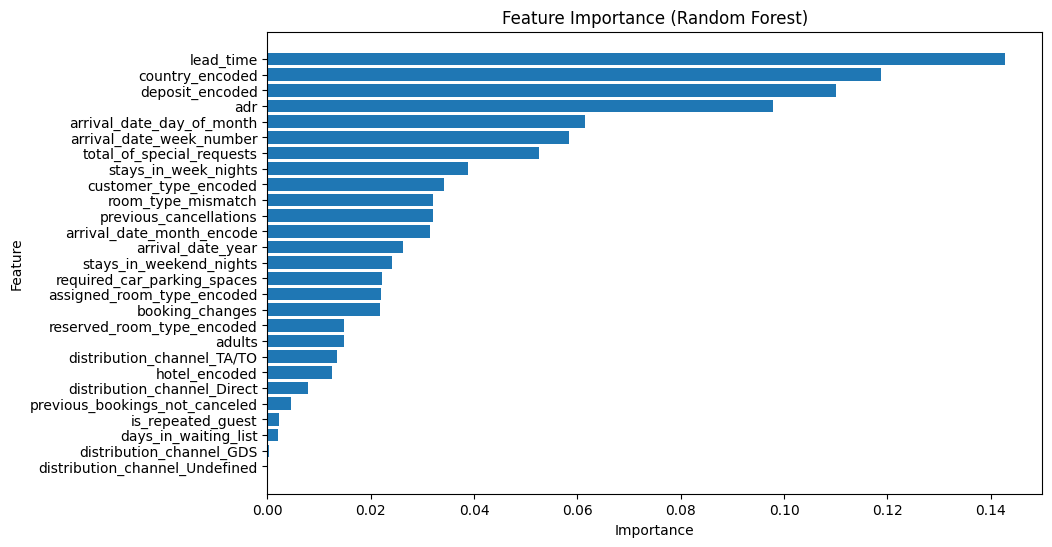

In [152]:
import matplotlib.pyplot as plt

# Random Forest Example
plt.figure(figsize=(10, 6))
plt.barh(rf_feature_importance['Feature'], rf_feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()  # Invert for better readability
plt.show()

## 5-fold cross validation

In [162]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Perform 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(logreg_reduced, X_train_reduced_scaled, y_train, cv=cv, scoring='accuracy')

# Report cross-validation performance
print("Cross-validation accuracy scores:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std CV accuracy:", np.std(cv_scores))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samp

Cross-validation accuracy scores: [0.78825315 0.7799822  0.78206471 0.78871322 0.78473458]
Mean CV accuracy: 0.7847495734964328
Std CV accuracy: 0.003403591481049793
